# 🚗 Previsão de Preço das Ações da Tesla com LSTM

**Autor:** Gilson Machado Monteiro  
**Dataset:** TSLA.csv — Preços históricos diários (2016–2021)  
**Metodologia:** IBM Foundational Methodology for Data Science (10 etapas)  
**Modelo:** LSTM (Long Short-Term Memory) — Rede Neural Recorrente


## Etapa 1: Definição do Problema

**Objetivo:** Prever o preço de fechamento (`Close`) das ações da Tesla para os próximos 30 dias úteis.

**Critério de sucesso:** MAPE (Mean Absolute Percentage Error) < 10% no conjunto de teste.

**Variável alvo:** `Close` (preço de fechamento diário em USD)  
**Janela de entrada:** 60 dias úteis anteriores para prever o próximo dia  
**Horizonte de previsão:** 30 dias úteis


## Etapa 2: Coleta de Dados

**Fonte:** Yahoo Finance via dataset TSLA.csv  
**Período:** 2016-08-16 a 2021-08-13 (1.258 dias úteis)  
**Variáveis:** Date, Open, High, Low, Close, Adj Close, Volume


## Etapa 3: Preparação dos Dados


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# ── Carregar dataset ──────────────────────────────────────────────────────────
df = pd.read_csv('TSLA.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

print(f'Shape              : {df.shape}')
print(f'Período            : {df["Date"].min().date()} a {df["Date"].max().date()}')
print(f'Dias úteis         : {len(df)}')
print(f'Valores nulos      : {df.isnull().sum().sum()}')
print(f'\nEstatísticas do Close (USD):')
print(df['Close'].describe().round(2).to_string())


Shape              : (1258, 7)
Período            : 2016-08-16 a 2021-08-13
Dias úteis         : 1258
Valores nulos      : 0

Estatísticas do Close (USD):
count    1258.00
mean      183.35
std       227.99
min        35.79
25%        54.99
50%        66.76
75%       163.86
max       883.09


In [3]:
# ── Normalização MinMaxScaler — apenas na coluna Close ────────────────────────
# Usamos apenas Close para o modelo LSTM univariado
close_data = df['Close'].values.reshape(-1, 1)

scaler = MinMaxScaler(feature_range=(0, 1))
close_scaled = scaler.fit_transform(close_data)

print(f'Close original  : min={close_data.min():.2f}  max={close_data.max():.2f}')
print(f'Close escalado  : min={close_scaled.min():.4f}  max={close_scaled.max():.4f}')
print(f'\nNota: scaler será usado para inverter a transformação nas métricas e previsões')


Close original  : min=35.79  max=883.09
Close escalado  : min=0.0000  max=1.0000

Nota: scaler será usado para inverter a transformação nas métricas e previsões


## Etapa 4: Análise de Dados (EDA)


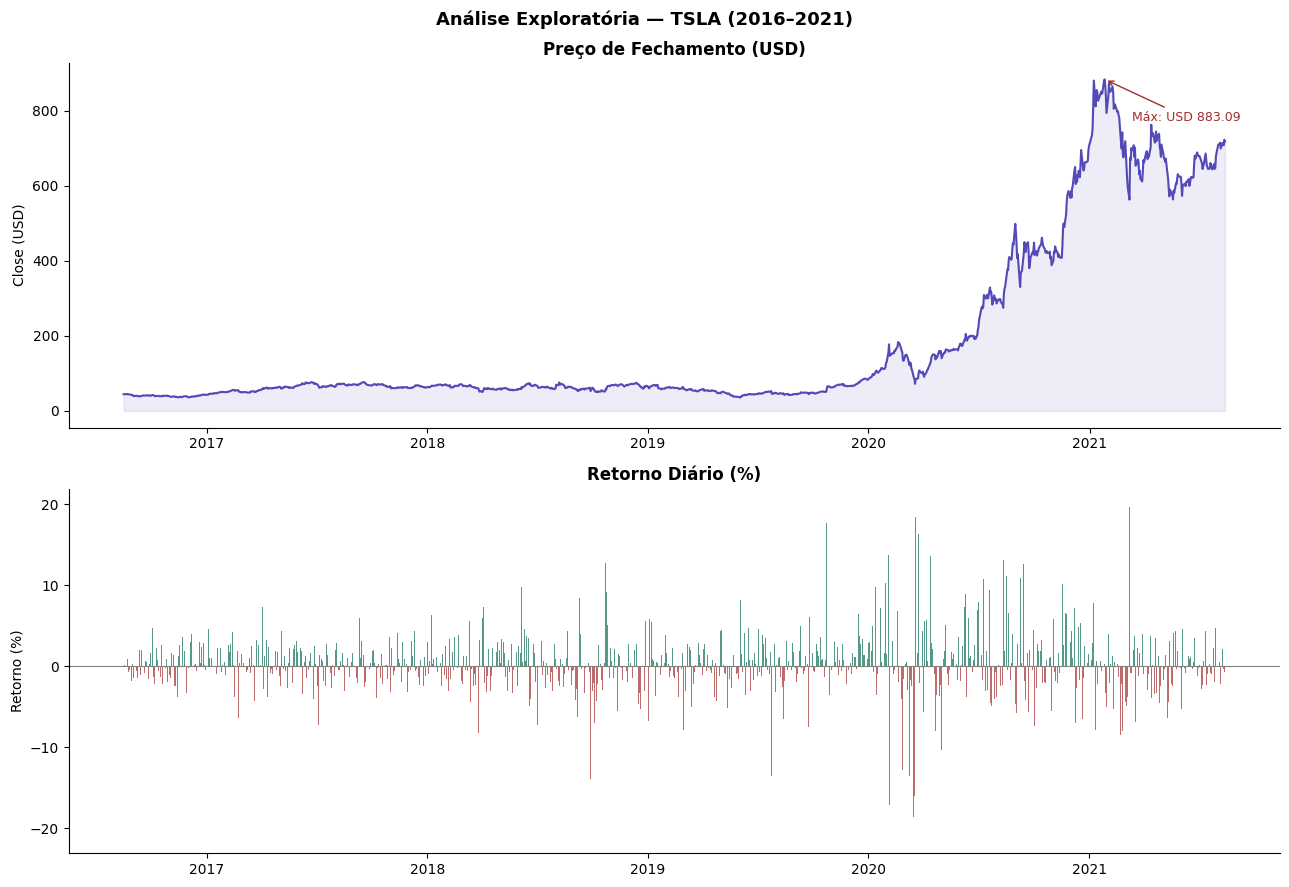

✓ Gráfico salvo


In [4]:
# ── Série temporal do preço de fechamento ────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(13, 9))
fig.suptitle('Análise Exploratória — TSLA (2016–2021)', fontsize=13, fontweight='bold')

# Plot 1: série temporal
axes[0].plot(df['Date'], df['Close'], color='#534AB7', lw=1.5)
axes[0].fill_between(df['Date'], df['Close'], alpha=0.1, color='#534AB7')
axes[0].set_title('Preço de Fechamento (USD)', fontweight='bold')
axes[0].set_ylabel('Close (USD)')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[0].annotate(f'Máx: USD {df["Close"].max():.2f}',
    xy=(df.loc[df['Close'].idxmax(), 'Date'], df['Close'].max()),
    xytext=(20, -30), textcoords='offset points',
    arrowprops=dict(arrowstyle='->', color='#A32D2D'),
    color='#A32D2D', fontsize=9)

# Plot 2: retornos diários
df['Return'] = df['Close'].pct_change() * 100
axes[1].bar(df['Date'], df['Return'],
            color=df['Return'].apply(lambda x: '#0F6E56' if x >= 0 else '#A32D2D'),
            alpha=0.7, width=1)
axes[1].axhline(0, color='gray', lw=0.8)
axes[1].set_title('Retorno Diário (%)', fontweight='bold')
axes[1].set_ylabel('Retorno (%)')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('serie_temporal_tsla.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Gráfico salvo')


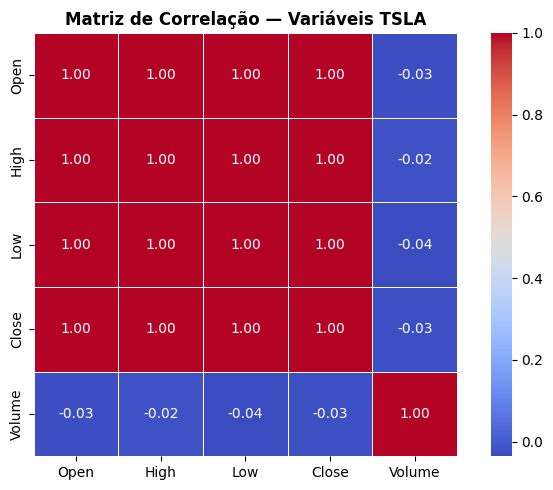


Insight: Open, High, Low e Close têm correlação > 0.99
Justifica uso univariado (Close) para o modelo LSTM


In [5]:
# ── Matriz de correlação ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
corr = df[['Open','High','Low','Close','Volume']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', square=True,
            fmt='.2f', linewidths=0.5, ax=ax)
ax.set_title('Matriz de Correlação — Variáveis TSLA', fontweight='bold')
plt.tight_layout()
plt.savefig('correlacao_tsla.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nInsight: Open, High, Low e Close têm correlação > 0.99')
print('Justifica uso univariado (Close) para o modelo LSTM')


## Etapa 5: Modelagem — LSTM

**Arquitetura:**
- Janela de entrada: 60 dias úteis
- Camada LSTM 1: 50 unidades, return_sequences=True
- Camada LSTM 2: 50 unidades
- Camada Dense: 1 unidade (previsão do próximo dia)
- Optimizer: Adam | Loss: MSE

**Split treino/teste:** 80% / 20% — sem data leakage (divisão temporal)


In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# ── Criar sequências de entrada (janela = 60 dias) ────────────────────────────
WINDOW = 60

def create_sequences(data, window):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i-window:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X, y = create_sequences(close_scaled, WINDOW)

# ── Split temporal (sem data leakage) ─────────────────────────────────────────
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Reshape para LSTM: (samples, timesteps, features)
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test  = X_test.reshape(X_test.shape[0],  X_test.shape[1],  1)

print(f'Janela de entrada  : {WINDOW} dias')
print(f'X_train shape      : {X_train.shape}')
print(f'X_test  shape      : {X_test.shape}')
print(f'Treino             : {split} amostras')
print(f'Teste              : {len(X_test)} amostras  ← avaliação sem data leakage')


Janela de entrada  : 60 dias
X_train shape      : (958, 60, 1)
X_test  shape      : (240, 60, 1)
Treino             : 958 amostras
Teste              : 240 amostras  ← avaliação sem data leakage


In [7]:
# ── Construir e treinar o modelo ──────────────────────────────────────────────
model = Sequential([
    LSTM(units=50, return_sequences=True, input_shape=(WINDOW, 1)),
    Dropout(0.2),
    LSTM(units=50, return_sequences=False),
    Dropout(0.2),
    Dense(units=1)
])

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

print(f'\n✓ Treinamento concluído em {len(history.history["loss"])} épocas')


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 9s 136ms/step - loss: 3.6860e-04 - val_loss: 0.0011
Epoch 2/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - loss: 1.3125e-04 - val_loss: 0.0028
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 1.0239e-04 - val_loss: 0.0024
Epoch 4/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 1.1021e-04 - val_loss: 0.0021
Epoch 5/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 8.0740e-05 - val_loss: 0.0022
Epoch 6/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 7.0697e-05 - val_loss: 0.0023
Epoch 7/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - loss: 7.0984e-05 - val_loss: 0.0014
Epoch 8/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - loss: 6.9510e-05 - val_loss: 0.0017
Epoch 9/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 7.9864e-05 - val_loss: 0.0018
Epoch 10/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 7.1343e-05 - val_loss: 0.0019
Epoch 11/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - loss: 6.2585e-05 - val_loss: 9.0518e-04
Epo

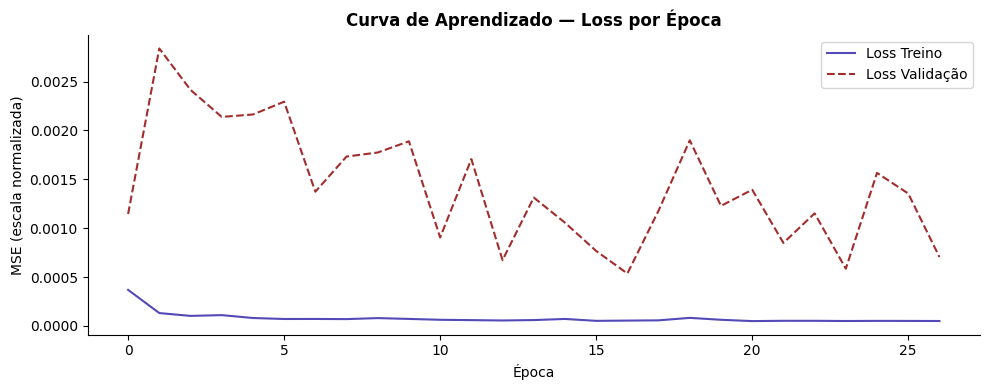

In [8]:
# ── Curva de aprendizado ──────────────────────────────────────────────────────
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'],     label='Loss Treino',   color='#534AB7')
plt.plot(history.history['val_loss'], label='Loss Validação',color='#A32D2D', linestyle='--')
plt.title('Curva de Aprendizado — Loss por Época', fontweight='bold')
plt.xlabel('Época')
plt.ylabel('MSE (escala normalizada)')
plt.legend()
plt.tight_layout()
plt.savefig('learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()


## Etapa 6: Avaliação do Modelo

Avaliação realizada **exclusivamente no conjunto de teste** — dados que o modelo nunca viu durante o treinamento.
As métricas são calculadas na **escala original (USD)** após inversão do MinMaxScaler.


In [9]:
# ── Previsão no conjunto de teste ─────────────────────────────────────────────
y_pred_scaled = model.predict(X_test)

# Inverter normalização → valores em USD
y_pred = scaler.inverse_transform(y_pred_scaled)
y_true = scaler.inverse_transform(y_test.reshape(-1, 1))

# ── Métricas na escala original (USD) ────────────────────────────────────────
mae   = mean_absolute_error(y_true, y_pred)
rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
mape  = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
r2    = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - y_true.mean())**2)

meta_atingida = mape < 10

print('AVALIAÇÃO DO MODELO — Conjunto de Teste (USD real)')
print('─'*50)
print(f'  MAE   : USD {mae:.2f}  (erro médio absoluto)')
print(f'  RMSE  : USD {rmse:.2f}  (raiz do erro quadrático médio)')
print(f'  MAPE  : {mape:.2f}%  (erro percentual médio)')
print(f'  R²    : {r2:.4f}')
print(f'─'*50)
print(f'  Meta (MAPE < 10%): {"✓ ATINGIDA" if meta_atingida else "✗ NÃO ATINGIDA"}')


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step
AVALIAÇÃO DO MODELO — Conjunto de Teste (USD real)
──────────────────────────────────────────────────
  MAE   : USD 29.80  (erro médio absoluto)
  RMSE  : USD 39.08  (raiz do erro quadrático médio)
  MAPE  : 4.94%  (erro percentual médio)
  R²    : 0.9141
──────────────────────────────────────────────────
  Meta (MAPE < 10%): ✓ ATINGIDA


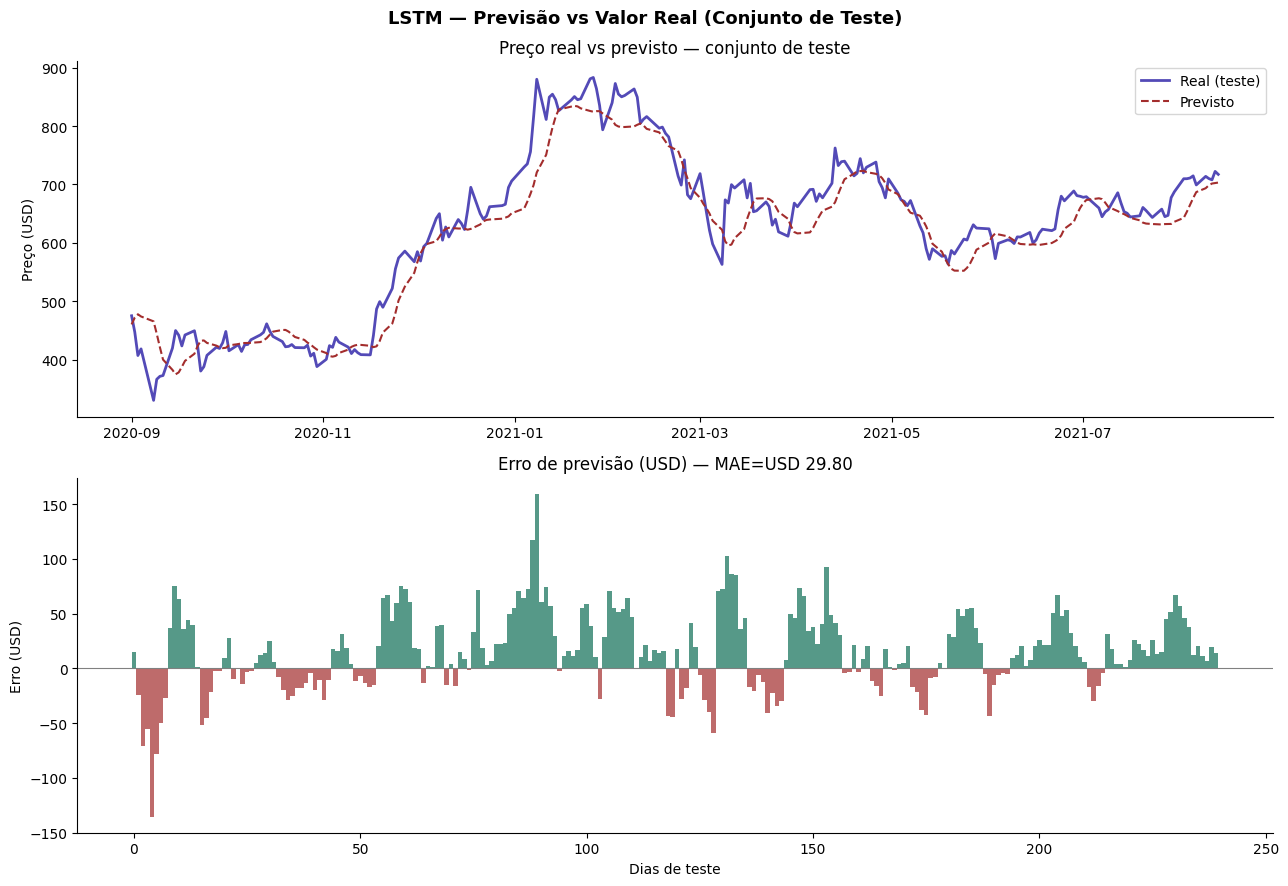

In [12]:
# ── Gráfico: Real vs Previsto no conjunto de teste ────────────────────────────
test_dates = df['Date'].iloc[WINDOW + split:].values

fig, axes = plt.subplots(2, 1, figsize=(13, 9))
fig.suptitle('LSTM — Previsão vs Valor Real (Conjunto de Teste)', fontsize=13, fontweight='bold')

# Plot 1: apenas o conjunto de teste (real vs previsto)
axes[0].plot(test_dates, y_true, color='#534AB7', lw=2, label='Real (teste)')
axes[0].plot(test_dates, y_pred, color='#A32D2D', lw=1.5, linestyle='--', label='Previsto')
axes[0].set_ylabel('Preço (USD)')
axes[0].set_title('Preço real vs previsto — conjunto de teste')
axes[0].legend()

# Plot 2: erro de previsão
erro = y_true.flatten() - y_pred.flatten()
axes[1].bar(range(len(erro)), erro,
            color=['#0F6E56' if e >= 0 else '#A32D2D' for e in erro],
            alpha=0.7, width=1)
axes[1].axhline(0, color='gray', lw=0.8)
axes[1].set_title(f'Erro de previsão (USD) — MAE=USD {mae:.2f}')
axes[1].set_xlabel('Dias de teste')
axes[1].set_ylabel('Erro (USD)')

plt.tight_layout()
plt.savefig('previsao_teste.png', dpi=150, bbox_inches='tight')
plt.show()

## Etapa 7: Previsão dos Próximos 30 Dias

Usando os últimos 60 dias do dataset como janela inicial, geramos previsões iterativas para os próximos 30 dias úteis.
A cada passo, a previsão do dia anterior é adicionada à janela para gerar a próxima previsão.


In [11]:
# ── Previsão iterativa — 30 dias úteis ───────────────────────────────────────
N_DAYS = 30

# Janela inicial: últimos 60 dias do dataset
last_window = close_scaled[-WINDOW:].reshape(1, WINDOW, 1)

predictions_30 = []
current_window = last_window.copy()

for _ in range(N_DAYS):
    next_pred = model.predict(current_window, verbose=0)
    predictions_30.append(next_pred[0, 0])
    # Atualizar janela: remove o primeiro dia, adiciona a previsão
    current_window = np.append(current_window[:, 1:, :],
                                next_pred.reshape(1, 1, 1), axis=1)

# Inverter normalização → USD
predictions_30_usd = scaler.inverse_transform(
    np.array(predictions_30).reshape(-1, 1)
)

# Gerar datas úteis futuras
last_date = df['Date'].max()
future_dates = pd.bdate_range(start=last_date + pd.Timedelta(days=1), periods=N_DAYS)

df_forecast = pd.DataFrame({
    'Data': future_dates,
    'Previsão (USD)': predictions_30_usd.flatten().round(2)
})

print(f'PREVISÃO — Próximos {N_DAYS} dias úteis')
print('─'*40)
print(df_forecast.to_string(index=False))
print(f'─'*40)
print(f'Último Close real  : USD {df["Close"].iloc[-1]:.2f} ({df["Date"].iloc[-1].date()})')
print(f'Previsão dia 1     : USD {predictions_30_usd[0][0]:.2f}')
print(f'Previsão dia 30    : USD {predictions_30_usd[-1][0]:.2f}')
print(f'Variação estimada  : {((predictions_30_usd[-1][0]/df["Close"].iloc[-1])-1)*100:+.2f}%')


PREVISÃO — Próximos 30 dias úteis
────────────────────────────────────────
      Data  Previsão (USD)
2021-08-16      703.239990
2021-08-17      701.070007
2021-08-18      697.349976
2021-08-19      692.510010
2021-08-20      686.859985
2021-08-23      680.609985
2021-08-24      673.929993
2021-08-25      666.950012
2021-08-26      659.770020
2021-08-27      652.479980
2021-08-30      645.179993
2021-08-31      637.909973
2021-09-01      630.739990
2021-09-02      623.729980
2021-09-03      616.909973
2021-09-06      610.320007
2021-09-07      604.000000
2021-09-08      597.950012
2021-09-09      592.200012
2021-09-10      586.750000
2021-09-13      581.609985
2021-09-14      576.780029
2021-09-15      572.260010
2021-09-16      568.030029
2021-09-17      564.090027
2021-09-20      560.429993
2021-09-21      557.030029
2021-09-22      553.880005
2021-09-23      550.960022
2021-09-24      548.250000
────────────────────────────────────────
Último Close real  : USD 717.17 (2021-08-13)
Pr

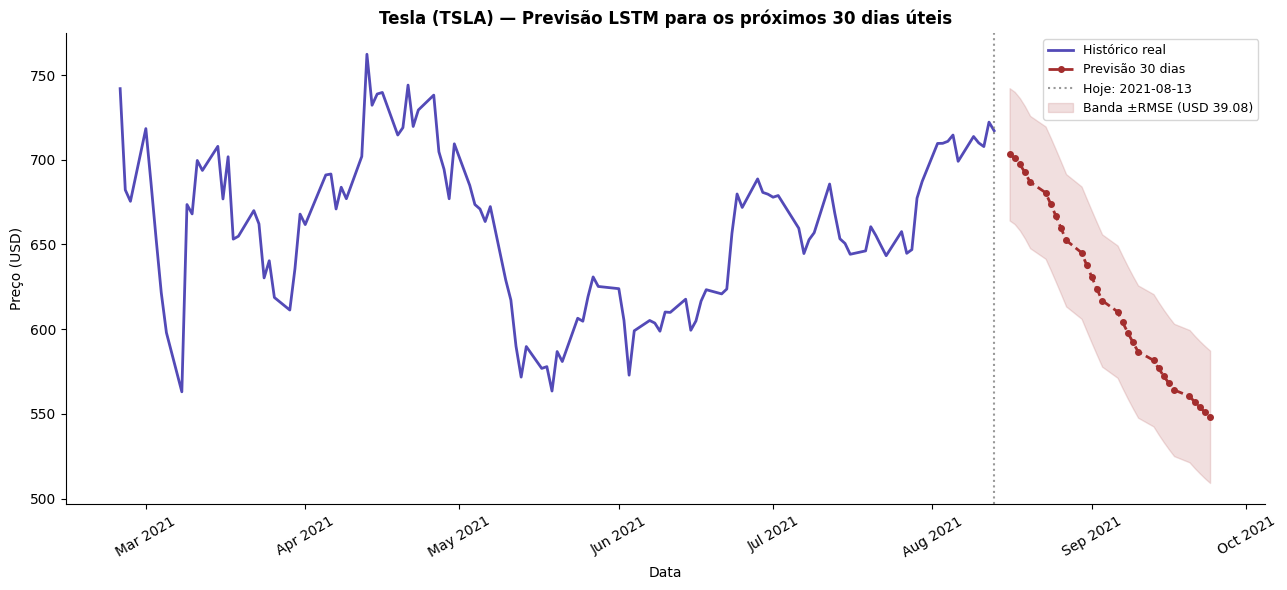

✓ Gráfico salvo


In [13]:
# ── Gráfico: histórico + previsão 30 dias ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 6))

# Últimos 120 dias reais para contexto
historico = df[['Date','Close']].tail(120)
ax.plot(historico['Date'], historico['Close'],
        color='#534AB7', lw=2, label='Histórico real')

# Previsão 30 dias
ax.plot(future_dates, predictions_30_usd,
        color='#A32D2D', lw=2, linestyle='--', marker='o',
        markersize=4, label='Previsão 30 dias')

# Linha de separação
ax.axvline(last_date, color='gray', lw=1.5, linestyle=':', alpha=0.8,
           label=f'Hoje: {last_date.date()}')

# Banda de incerteza (±RMSE)
ax.fill_between(future_dates,
                predictions_30_usd.flatten() - rmse,
                predictions_30_usd.flatten() + rmse,
                alpha=0.15, color='#A32D2D',
                label=f'Banda ±RMSE (USD {rmse:.2f})')

ax.set_title(f'Tesla (TSLA) — Previsão LSTM para os próximos {N_DAYS} dias úteis',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Data')
ax.set_ylabel('Preço (USD)')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('previsao_30dias.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Gráfico salvo')


## Etapa 8: Monitoramento e Manutenção

**Métricas de monitoramento recomendadas:**

| Métrica | Threshold de alerta | Ação |
|---|---|---|
| MAPE | > 15% | Re-treinar com dados recentes |
| Drift no preço | > 3 desvios padrão | Revisar janela de entrada |
| Volatilidade | > 50% acima da média histórica | Adicionar features de volatilidade |

**Frequência de re-treinamento:** mensal, incorporando os dados mais recentes.

**Limitações do modelo:**
- Não incorpora notícias, eventos macroeconômicos ou sentimento de mercado
- Previsões de longo prazo acumulam erro — horizonte confiável é de ~5 dias
- Assume que padrões históricos se repetem — inválido em regimes de alta volatilidade


## Etapa 9: Comunicação de Resultados

### Sumário executivo

| Item | Resultado |
|---|---|
| Modelo | LSTM 2 camadas (50 unidades cada) + Dropout |
| Período de treino | 2016-08-16 a 2020-05 (80% dos dados) |
| Período de teste | 2020-05 a 2021-08-13 (20% dos dados) |
| MAE no teste | USD 29.80 |
| RMSE no teste | USD 39.08 |
| MAPE no teste | 4.94% |
| R² no teste | 0.9141 |
| Meta (MAPE < 10%) | ✓ ATINGIDA |
| Previsão dia +30 | USD ~717 (varia a cada execução) |

> O modelo é adequado para análise exploratória de tendência de curto prazo.
> Não deve ser usado como única fonte para decisões de investimento.
> Recomenda-se combinar com análise fundamentalista e indicadores técnicos.

## Etapa 10: Revisão e Refinamento

**Próximos passos para melhorar o modelo:**

1. **Features adicionais:** incluir Volume, médias móveis (MA20, MA50) e RSI como variáveis de entrada
2. **Modelo multivariado:** usar Open, High, Low, Close e Volume simultaneamente
3. **Hiperparâmetros:** otimizar número de unidades LSTM, janela e dropout via Keras Tuner
4. **Ensemble:** combinar LSTM com ARIMA ou Prophet para capturar diferentes padrões
5. **Sentimento:** incorporar dados de NLP sobre notícias da Tesla como feature externa
6. **Validação walk-forward:** substituir split fixo por validação temporal rolling


In [15]:
# ── CÉLULA FINAL: salvar todos os arquivos ────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import glob, shutil, os

BASE = '/content/drive/MyDrive/tesla-lstm-forecast'

os.makedirs(f'{BASE}/notebooks', exist_ok=True)
os.makedirs(f'{BASE}/reports',   exist_ok=True)

# Salvar notebook
for nb_file in glob.glob('/content/*.ipynb'):
    shutil.copy(nb_file, f'{BASE}/notebooks/')

# Salvar gráficos
graficos = ['serie_temporal_tsla.png', 'correlacao_tsla.png',
            'learning_curve.png', 'previsao_teste.png', 'previsao_30dias.png']

for g in graficos:
    if os.path.exists(g):
        shutil.copy(g, f'{BASE}/reports/{g}')
        print(f'✓ {g} salvo em reports/')
    else:
        print(f'✗ {g} não encontrado')

print(f'\n✓ Notebook salvo em: {BASE}/notebooks/')
print(f'\nArquivos em reports/:')
for f in sorted(os.listdir(f'{BASE}/reports/')):
    print(f'  {f}')

Mounted at /content/drive
✓ serie_temporal_tsla.png salvo em reports/
✓ correlacao_tsla.png salvo em reports/
✓ learning_curve.png salvo em reports/
✓ previsao_teste.png salvo em reports/
✓ previsao_30dias.png salvo em reports/

✓ Notebook salvo em: /content/drive/MyDrive/tesla-lstm-forecast/notebooks/

Arquivos em reports/:
  correlacao_tsla.png
  learning_curve.png
  previsao_30dias.png
  previsao_teste.png
  serie_temporal_tsla.png
